In [1]:
# ---------------------------------------------------------------------------------- #
# CAMIA: Context‑Aware Membership Inference Attack – **Debugged & Streamlined**       #
# ---------------------------------------------------------------------------------- #
#   • Cell‑0  –  Imports, device config, global knobs                                 #
#   • Cell‑1  –  Helper for canonical HuggingFace model names                         #
#   • Cell‑2  –  Core signal extraction (fixed signs, faster LZ‑diff)                 #
#   • Cell‑3  –  P‑value combiners + Group‑PCA / LogReg attack (clean & weighted)     #
#   • Cell‑4  –  ROC/PR metric helpers                                                #
#   • Cell‑5  –  Minimal demo / grid‑search driver                                    #
#   • Cell‑6  –  Optional diagnostics & per‑feature tables                            #
#                                                                                        
# **Bug‑fixes & changes vs original**                                                 #
#   ✓ removed duplicated / legacy cells                                               #
#   ✓ fixed sign of `slope_*`, `apen_*`, and `lz_bins*_rep{1,2}_diff`                 #
#   ✓ proper weighting of the neighbourhood p‑value in all combiners                  #
#   ✓ single global z‑score  *or* per‑group whitening (toggle via `USE_WHITENING`)    #
#   ✓ neighbour gamma applied on coefficients (no variance distortion)                #
#   ✓ memory‑safe CE batching, early‑exit cache, tqdm progress                        #
#   ✓ explicit seed control for full determinism                                      #
# ---------------------------------------------------------------------------------- #

# ╔════════════════════════════════════════════════════════════════════════════╗
# ║  Cell‑0 · imports & global config                                          ║
# ╚════════════════════════════════════════════════════════════════════════════╝
import os, json, math, random, itertools, bisect, glob, textwrap
from collections import defaultdict
from itertools import islice

import numpy as np
import pandas as pd
import torch, torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets  import load_dataset
from tqdm.auto import tqdm, trange
from sklearn.decomposition import PCA
from sklearn.linear_model  import LogisticRegression
from sklearn.metrics       import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# reproducibility -------------------------------------------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# device ----------------------------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✔ using {DEVICE}")

# master knobs – tweak here ----------------------------------------------------
class C:                      # simple namespace
    MAX_LEN_CE       = 1024   # LM loss truncation
    CE_SUB_BS        = 16     # mini‑batch for CE pass
    FP16_CE          = True
    # ‑‑ neighbour settings
    NEI_K            = 0      # neighbours per passage (0 ⇒ vanilla CAMIA)
    NEI_WEIGHT       = 9      # weight in p‑value combiner (Edgington et al.)
    NEI_GAMMA        = 1.0    # multiplicative boost inside LogReg attack
    # signal hyper‑params
    CUT_TPRIMES      = {"T":None,"200":200,"300":300}
    CB_TAU_LIST      = [1,2,3]
    LZ_BIN_LIST      = [3,4,5]
    SLOPE_TPRIMES    = [600,800,1000]
    APEN_TPRIMES     = [600,800,1000]
    STORE_FULL_SEQ   = False  # saves RAM, switch on for diagnostics only
        # ── new elbow-signal hyper-params ────────────────────────────────
    ELBOW_SKIP_LEFT    = 25        # ignore the first/last ELBOW_SKIP tokens
    ELBOW_SKIP_RIGHT   = 0.25
    FLAT_SKIP_LEFT     = 0
    FLAT_SKIP_RIGHT    = 25
    ELBOW_STORE_I = False      # keep the raw index for later neighbour gen.
    FLAT_EPS = 1e-3

✔ using cuda


In [2]:
# ╔════════════════════════════════════════════════════════════════════════════╗
# ║  Cell‑1 · helper: (suite,size) → HF repo                                    ║
# ╚════════════════════════════════════════════════════════════════════════════╝

def get_model_name(suite: str, size: str, deduped: bool = False) -> str:
    suite, size = suite.lower(), size.lower()
    if suite == "pythia":
        base = f"EleutherAI/pythia-{size}"
        return base + ("-deduped" if deduped else "")
    if suite == "gpt-neo":
        mapping = {"125m":"125M","1.3b":"1.3B","2.7b":"2.7B"}
        if size not in mapping:
            raise ValueError(f"Unsupported GPT‑Neo size: {size}")
        return f"EleutherAI/gpt-neo-{mapping[size]}"
    raise ValueError(f"Unknown suite: {suite}")

# ── dynamic per-GPU ceiling ─────────────────────────────────────────────
def fit_batch_size(model) -> None:
    """
    Shrinks C.CE_SUB_BS until one forward pass fits the free VRAM.
    No impact on the numeric results (only speed).
    """
    bs = C.CE_SUB_BS
    while True:
        try:
            dummy = torch.ones(bs, C.MAX_LEN_CE, dtype=torch.long,
                               device=DEVICE)
            with torch.amp.autocast(device_type='cuda',
                                    dtype=torch.float16,
                                    enabled=C.FP16_CE):
                model(dummy, attention_mask=torch.ones_like(dummy))
            break
        except torch.cuda.OutOfMemoryError:
            bs //= 2
            assert bs >= 1, "even BS=1 does not fit – lower MAX_LEN_CE"
            torch.cuda.empty_cache()
    if bs != C.CE_SUB_BS:
        print(f"⚠️  Low-VRAM mode → CE_SUB_BS={bs}")
    C.CE_SUB_BS = bs


In [8]:
# ╔════════════════════════════════════════════════════════════════════════════╗
# ║  Cell‑2 · Signal extraction (bug‑fixed)                                     ║
# ╚════════════════════════════════════════════════════════════════════════════╝
#  –  build 72 numeric signals per passage (CAMIA §3)                           

from contextlib import nullcontext
from torch import autocast as _amp

safe_mean = lambda arr: float(np.mean(arr)) if len(arr) else 0.0
_diff     = lambda a,b: (a-b) if (np.isfinite(a) and np.isfinite(b)) else 0.0

# --------------------------------------------------------------------------- #
#   *Neighbour loading helper* – One‑liner wrapper; caches stay external      #
# --------------------------------------------------------------------------- #

def load_cached_neighbours(domain, split, tag):
    if C.NEI_K == 0:
        return None
    path = f"cache_flat_pythia1.4b_dedup/neigh_{domain}_{split}_{tag}.json"
    with open(path) as f:
        table = json.load(f)
    # pad / clip so every row has exactly K entries (important!)
    for i,row in enumerate(table):
        if len(row) < C.NEI_K:
            table[i] = row + row[:1]*(C.NEI_K-len(row))
        else:
            table[i] = row[:C.NEI_K]
    return table

# --------------------------------------------------------------------------- #
#   Core primitives: CE losses, sequence stats, LZ complexity, slope, ApEn    #
# --------------------------------------------------------------------------- #

@torch.no_grad()
def _ce_losses(texts, model, tok, slice_len: int = 256):
    if not texts:
        return []

    enc = tok(texts,
              return_tensors="pt",
              padding=True,
              truncation=True,
              max_length=C.MAX_LEN_CE
             ).to(model.device)

    with torch.amp.autocast(device_type='cuda',
                            dtype=torch.float16,
                            enabled=C.FP16_CE):
        logits = model(enc.input_ids,
                       use_cache = False,
                       attention_mask=enc.attention_mask).logits[:, :-1]

    tgt  = enc.input_ids[:, 1:]
    mask = enc.attention_mask[:, 1:]

    B, T, V = logits.shape
    slabs   = []

    for s in range(0, T, slice_len):                 # fp32 slice streaming
        e      = min(s + slice_len, T)
        slab   = logits[:, s:e].float()              # (B,S,V)
        tgt_sl = tgt[:,   s:e]

        logp = torch.log_softmax(slab, dim=-1)
        ce   = -logp.gather(-1, tgt_sl.unsqueeze(-1)).squeeze(-1)
        slabs.append(ce)

        del slab, logp, ce
        torch.cuda.empty_cache()

    ce_full = torch.cat(slabs, dim=1)                # (B,T)
    return [ce_full[i, : int(mask[i].sum())].tolist() for i in range(B)]


# ------------------------------------------------------------- helper stats #

def _ce_stream(text_list, model, tok,
               stream_bs=C.CE_SUB_BS, max_len=C.MAX_LEN_CE):
    out = []
    for i in range(0, len(text_list), stream_bs):
        out.extend(_ce_losses(text_list[i:i+stream_bs], model, tok))
        torch.cuda.empty_cache()
    return out


def _count_below(seq, thr, Tprime):
    sub = seq if Tprime is None else seq[:Tprime]
    return sum(v<=thr for v in sub)/len(sub) if sub else 0.0

def _count_below_mean(seq, L=None):
    sl = seq if L is None else seq[:L]
    if not sl:
        return 0.0
    m = safe_mean(sl)
    return sum(v<=m for v in sl)/len(sl)

def _count_below_prev_mean(seq, L=None):
    sl = seq if L is None else seq[:L]
    if len(sl)<=1:
        return 0.0
    below,csum = 0, sl[0]
    for i,v in enumerate(sl[1:],1):
        below += v<=csum/i; csum+=v
    return below/(len(sl)-1)

# -------- LZ76 complexity ---------------------------------------------------

def _lz_complexity(seq, bins, Tprime):
    sub = seq if Tprime is None else seq[:Tprime]
    if not sub:
        return 0.0
    arr = np.asarray(sub); lo,hi = arr.min(), arr.max()
    if hi-lo < 1e-12:
        return 1.0
    edges   = np.linspace(lo, hi+1e-9, bins)
    symbols = ''.join(chr(65+np.digitize(v,edges)) for v in arr)
    i,c=0,1
    while i<len(symbols)-1:
        l=1
        while symbols[i:i+l] in symbols[:i] and i+l<len(symbols):
            l+=1
        i+=l; c+=1
    return float(c)

# -------- slope & ApEn ------------------------------------------------------

def _replicate_if_short(seq, desired):
    if not seq or len(seq)>=desired:
        return seq
    out=list(seq)
    while len(out)<desired:
        out.extend(seq[:desired-len(out)])
    return out

def _slope_signal(loss_seq, Tprime):
    if not loss_seq:
        return 0.0
    y = np.asarray(_replicate_if_short(loss_seq, Tprime)[:Tprime])
    x = np.arange(len(y))
    var = np.mean((x - x.mean())**2)
    if var==0:
        return 0.0
    cov = np.mean((x - x.mean())*(y - y.mean()))
    return float(cov/var)   # negative for members

def _approximate_entropy(seq, Tprime, m=8, r=0.8):
    seq = _replicate_if_short(seq, Tprime)[:Tprime]
    if len(seq)<m+2:
        return 0.0
    vals=np.asarray(seq)
    def _phi(mm):
        N=len(vals)-mm+1
        if N<=0:
            return 0.0
        patterns=np.array([vals[i:i+mm] for i in range(N)])
        C=np.sum(np.max(np.abs(patterns[:,None]-patterns[None,:]),axis=2)<=r,axis=0)/N
        return np.mean(np.log(C+1e-12))
    return float(_phi(m)-_phi(m+1))

# -------- token diversity ---------------------------------------------------

def token_diversity(text,tok):
    toks=tok.tokenize(text)
    return len(set(toks))/len(toks) if toks else 0.0

# --------------------------------------------------------------------------- #
#   Neighbour Δ helper (vectorised, memory‑safe)                              #
# --------------------------------------------------------------------------- #

@torch.no_grad()
def _mean_ce_many(texts, model, tok, bs: int = 4):
    losses = []
    for i in range(0, len(texts), bs):
        losses.extend(
            safe_mean(s) for s in _ce_losses(texts[i:i+bs], model, tok)
        )
        torch.cuda.empty_cache()
    return np.asarray(losses, dtype=np.float32)

def add_nei_delta(base_dicts, neighbour_table, model, tok):
    if C.NEI_K == 0 or neighbour_table is None:
        return base_dicts

    neighbour_table = neighbour_table[:len(base_dicts)]
    flat = list(itertools.chain.from_iterable(row for row in neighbour_table))
    nei_ce = _mean_ce_many(flat, model, tok).reshape(len(base_dicts), C.NEI_K)

    out = []
    for d, nei in zip(base_dicts, nei_ce):
        # use stored sequence when available, otherwise the already-computed mean CE
        base_ce = safe_mean(d["loss_seq_orig"]) if "loss_seq_orig" in d else d["cut_T"]
        nd = d.copy()
        nd["nei_delta"] = float(base_ce - nei.mean())
        out.append(nd)
    return out


# --------------------------------------------------------------------------- #
#   gather_signals_for_batch – builds one dict per passage                     #
# --------------------------------------------------------------------------- #

@torch.no_grad()
def gather_signals_for_batch(texts, model, tok, neighbour_rows=None):
    max_len = C.MAX_LEN_CE

    # 1) 3× truncations × 3× repetitions
    variants={(t,r):[] for t in ("T","200","300") for r in (0,1,2)}

    def _reps(txt,tp):
        if tp is None:
            base=txt
        else:
            ids=tok(txt)["input_ids"][:tp]
            base=tok.decode(ids,skip_special_tokens=True)
        return base, f"{base} {base}", f"{base} {base} {base}"

    for t in texts:
        for tag,tp in (("T",None),("200",200),("300",300)):
            b,r1,r2=_reps(t,tp)
            variants[(tag,0)].append(b)
            variants[(tag,1)].append(r1)
            variants[(tag,2)].append(r2)

    # batched CE
    losses = {k: _ce_stream(v, model, tok) for k, v in variants.items()}

    # 2) build feature dicts
    feats=[]
    for i,orig in enumerate(texts):
        L=lambda tag,rp: losses[(tag,rp)][i]
        d={}

        # — ❶ cut / cal / ppl / calppl —
        for tag,tp in C.CUT_TPRIMES.items():
            if tp is None:
                txt_trim=orig
            else:
                ids_trim=tok(orig)["input_ids"][:tp]
                txt_trim=tok.decode(ids_trim,skip_special_tokens=True)
            div=max(token_diversity(txt_trim,tok),1e-12)
            lb,lr1,lr2 = L(tag,0),L(tag,1),L(tag,2)
            for fam,post in (
                ("cut", lambda x:x),
                ("cal", lambda x:x/div),
                ("ppl", lambda x:math.exp(x)),
                ("calppl", lambda x:math.exp(x)/div)):
                vb,vr1,vr2=map(post,map(safe_mean,(lb,lr1,lr2)))
                d[f"{fam}_{tag}"]=vb
                d[f"{fam}_{tag}_rep1_diff"]=_diff(vb,vr1)  
                d[f"{fam}_{tag}_rep2_diff"]=_diff(vb,vr2)

        # — ❷ count‑below CONST (invert) —
        for tau in C.CB_TAU_LIST:
            lb,lr1,lr2=L("200",0),L("200",1),L("200",2)
            b,r1,r2=(_count_below(x,tau,200) for x in (lb,lr1,lr2))
            b,r1,r2=(1-b,1-r1,1-r2)
            k=f"cb_const{tau}"
            d[k]=b; d[f"{k}_rep1_diff"]=_diff(b,r1); d[f"{k}_rep2_diff"]=_diff(b,r2)

        # — ❸ count‑below MEAN/prev‑mean (invert) —
        for tag in C.CUT_TPRIMES:
            lb,lr1,lr2=L(tag,0),L(tag,1),L(tag,2)
            base,r1,r2=(_count_below_mean(x) for x in (lb,lr1,lr2))
            base,r1,r2=(1-base,1-r1,1-r2)
            k=f"cbm_{tag}"
            d[k]=base 
            d[f"{k}_rep1_diff"]=_diff(base,r1)
            d[f"{k}_rep2_diff"]=_diff(base,r2)
            d[f"cbpm_{tag}"]=1-_count_below_prev_mean(lb)

        # — ❹ LZ, slope, ApEn —
        for bins in C.LZ_BIN_LIST:
            lb,lr1,lr2 = L("200",0),L("200",1),L("200",2)
            b,r1,r2    = (_lz_complexity(x,bins,200) for x in (lb,lr1,lr2))
            k=f"lz_bins{bins}"
            d[k]=b
            d[f"{k}_rep1_diff"]=_diff(r1,b)          
            d[f"{k}_rep2_diff"]=_diff(r2,b)

        # expensive signals -------------------------------------------------------
        if C.SLOPE_TPRIMES or C.APEN_TPRIMES or C.STORE_FULL_SEQ or C.ELBOW_STORE_I:
            lb_full = L("T", 0)

            # classic slope & ApEn
            for tp in C.SLOPE_TPRIMES:
                d[f"slope_{tp}"] = -_slope_signal(lb_full, tp)
            for tp in C.APEN_TPRIMES:
                d[f"apen_{tp}"]  = -_approximate_entropy(lb_full, tp)

            # unified elbow + flat
            ei, f_e, da, fi, f_f = _elbow_and_flat_signals(
                    lb_full,
                    skip_elbow_left  = C.ELBOW_SKIP_LEFT,
                    skip_elbow_right = C.ELBOW_SKIP_RIGHT,
                    skip_flat_left   = C.FLAT_SKIP_LEFT,
                    skip_flat_right  = C.FLAT_SKIP_RIGHT,
                    flat_eps_init    = C.FLAT_EPS)

            d["elbow_frac"]        = f_e
            d["elbow_delta_slope"] = abs(da)
            d["flat_frac"]         = f_f

            if C.ELBOW_STORE_I:
                d["elbow_idx"] = ei     # for neighbour window (not part of attack)
                d["flat_idx"]  = fi

            if C.STORE_FULL_SEQ:
                d["loss_seq_orig"] = lb_full

        feats.append(d)

    # neighbour delta (optional)
    if C.NEI_K and neighbour_rows is not None:
        feats = add_nei_delta(feats, neighbour_rows, model, tok)

    return feats

def gather_signals_for_dataset(texts, model, tokenizer, *,
                               tag: str,
                               domain_name: str,
                               split_name: str,
                               batch_size: int = 32,
                               **kw):
    """
    Convenience wrapper: iterates over `texts` in manageable batches
    and attaches the correct neighbour rows (if NEI_K>0).
    All extra kwargs are forwarded to `gather_signals_for_batch`.
    """
    nei_tbl = load_cached_neighbours(domain_name, split_name, tag)
    out = []

    for s in tqdm(range(0, len(texts), batch_size),
                  desc=f"Signal-extraction ({tag})"):
        e = s + batch_size
        out.extend(
            gather_signals_for_batch(
                texts[s:e], model, tokenizer,
                neighbour_rows=None if nei_tbl is None else nei_tbl[s:e],
                **kw
            )
        )
        torch.cuda.empty_cache()

    return out

# ───────── unified elbow + flat helper  (O(T) · single pass) ──────────
def _elbow_and_flat_signals(
        seq,
        *,                          # force keyword args
        skip_elbow_left   : int   = C.ELBOW_SKIP_LEFT,
        skip_elbow_right  : float = C.ELBOW_SKIP_RIGHT,
        skip_flat_right   : int   = C.FLAT_SKIP_RIGHT,
        skip_flat_left    : int   = C.FLAT_SKIP_LEFT, 
        flat_eps_init: float = C.FLAT_EPS,
        flat_eps_max : float = 8 * C.FLAT_EPS,
):
    """
    Returns  (ei , f_elbow , delta_a , fi , f_flat)

      ei       best-elbow index   (None if L < 2·skip_elbow+1)
      f_elbow  ei / L             (0.0 if ei is None)
      delta_a  signed Δ-slope at ei    (0.0 if ei is None)

      fi       first suffix with |a_suffix| ≤ ε (or shallowest suffix)
      f_flat   fi / L

    *One* forward pass: prefix/suffix slopes are computed once and then
    sliced differently for the elbow and flat searches.
    """

    L = len(seq)
    if L < skip_elbow_left + skip_elbow_right*L + 1:              # too short even for elbow
        return None, 0.0, 0.0, None, 0.0

    y = np.asarray(seq, dtype=np.float32)
    x = np.arange(L,   dtype=np.float32)

    # cumulative prefix sums -----------------------------------------------
    Sy  = np.cumsum(y)
    Sx  = np.cumsum(x)
    Sx2 = np.cumsum(x * x)
    Sxy = np.cumsum(x * y)

    idxs_all  = np.arange(1, L, dtype=np.int32)     # 1 … L-1  (suffix ≥1)
    idxm1_all = idxs_all - 1

    # prefix slopes a₁(t) for ALL t ----------------------------------------
    n1   = idxs_all + 1.0
    sy1  = Sy[idxs_all]
    sx1  = Sx[idxs_all]
    sx21 = Sx2[idxs_all]
    sxy1 = Sxy[idxs_all]
    denom1 = n1 * sx21 - sx1 * sx1
    a1 = np.where(denom1 != 0,
                  (n1 * sxy1 - sx1 * sy1) / denom1,
                  np.nan)

    # suffix slopes a₂(t) for ALL t ----------------------------------------
    n2   = L - idxs_all
    sy2  = Sy[-1]  - Sy[idxm1_all]
    sx2  = Sx[-1]  - Sx[idxm1_all]
    sx22 = Sx2[-1] - Sx2[idxm1_all]
    sxy2 = Sxy[-1] - Sxy[idxm1_all]
    denom2 = n2 * sx22 - sx2 * sx2
    a2 = np.where(denom2 != 0,
                  (n2 * sxy2 - sx2 * sy2) / denom2,
                  np.nan)

    # --------------- ELBOW part -------------------------------------------
    right_cut = int(np.floor(L * (1.0 - skip_elbow_right)))
    elbow_mask = (idxs_all >= skip_elbow_left) & (idxs_all < right_cut)
    delta      = a1 - a2
    abs_delta  = np.abs(delta)
    abs_delta[~elbow_mask] = np.nan

    if np.all(np.isnan(abs_delta)):
        ei, f_elbow, delta_a = None, 0.0, 0.0
    else:
        jbest   = np.nanargmax(abs_delta)
        ei      = int(idxs_all[jbest])
        f_elbow = ei / L
        delta_a = float(delta[jbest])       # signed

    # --------------- FLAT part --------------------------------------------
    fi, f_flat = None, 0.0
    abs_a2 = np.abs(a2)
    flat_mask = (idxs_all >= skip_flat_left) & (idxs_all <= L - 1 - skip_flat_right)
    
    eps = flat_eps_init
    while eps <= flat_eps_max and fi is None:
        m = flat_mask & (abs_a2 < eps)
        if m.any():
            fi     = int(idxs_all[m][0])  # first idx satisfying criterion
            f_flat = fi / L
        else:
            eps *= 2.0

    # fallback: shallowest suffix if really nothing matched
    if fi is None:
        cand = abs_a2[flat_mask]          # ⟵ may be all-NaN
        if np.all(np.isnan(cand)):
            # every suffix slope undefined  → treat as “no flat” at all
            fi, f_flat = None, 0.0
        else:
            jmin   = np.nanargmin(cand)
            fi     = int(idxs_all[flat_mask][jmin])
            f_flat = fi / L

    return ei, f_elbow, delta_a, fi, f_flat



In [5]:
# ╔════════════════════════════════════════════════════════════════════════════╗
# ║  Cell‑3 · Combiners & attack models                                        ║
# ╚════════════════════════════════════════════════════════════════════════════╝

CLIP=1e-5
USE_WHITENING=True   # toggle – if True we do per‑group whitening and **omit** global z‑score

# ---------- helper: group name ---------------------------------------------

def _group(k: str) -> str:
    # dedicated 1-D buckets
    if k == "nei_delta":            return "nei"
    if k == "elbow_frac":           return "elbow_frac"
    if k == "elbow_delta_slope":    return "elbow_delta_slope"
    if k == "flat_frac":            return "flat_frac"

    # regular multi-feature families
    for p in ("cut","calppl","ppl","cal","cb_const",
              "cbm","cbpm","lz_bins","slope","apen"):
        if k.startswith(p):
            return p.split("_")[0]

    return "misc"


# ---------- p‑value handling (weighted) -------------------------------------

def _pvalue(x, ref_arr):
    n=ref_arr.size
    rank=np.searchsorted(ref_arr, x, side="right")
    return rank/(n+1)


def _combine_weighted(pvals, method="edgington"):
    """pvals is list[(p,w)]"""
    if not pvals:
        return 0.0
    clip=lambda p: min(max(p,CLIP),1-CLIP)
    if method=="edgington":
        return sum(w*p for p,w in pvals)
    if method=="fisher":
        return sum(-2*w*math.log(clip(p)) for p,w in pvals)
    if method=="pearson":
        return sum(-2*w*math.log(clip(1-p)) for p,w in pvals)
    if method=="george":
        return sum(w*math.log(clip(p)/(1-clip(p))) for p,w in pvals)
    raise ValueError(method)


def build_reference(nonmember_dicts):
    ref=defaultdict(list)
    for d in nonmember_dicts:
        for k,v in d.items():
            if isinstance(v,(int,float)) and np.isfinite(v):
                ref[k].append(v)
    for k,arr in ref.items():
        ref[k]=np.sort(np.asarray(arr,dtype=np.float32))
    return ref


def pv_score_batch(dicts, ref, method="edgington"):
    scores=[]
    for d in dicts:
        pvals=[]
        for k,v in d.items():
            if k not in ref or not np.isfinite(v):
                continue
            w = (C.NEI_WEIGHT if k=="nei_delta" else 1)
            pvals.append((_pvalue(v, ref[k]), w))
        scores.append(_combine_weighted(pvals, method))
    return scores

# ---------- Group-PCA + LogReg --------------------------------------------
PCA_DIM_PER_GROUP = 2          # unchanged

def logistic_fit(member_dicts, nonmember_dicts):
    Xd = member_dicts + nonmember_dicts
    y  = np.array([1]*len(member_dicts) + [0]*len(nonmember_dicts))

    # 1) raw matrix
    keys = sorted({k for d in Xd for k,v in d.items()
                   if isinstance(v,(int,float)) and np.isfinite(v)})
    raw  = np.array([[d.get(k,0.0) for k in keys] for d in Xd],
                    dtype=np.float32)
    raw  = np.nan_to_num(raw, nan=0.0, posinf=0.0, neginf=0.0, copy=False)  # NEW
    
    # 2) centre & scale once – always
    mu, sigma = raw.mean(0), raw.std(0) + 1e-9
    raw_z     = (raw - mu) / sigma

    # 3) per-group PCA / whitening
    grp2cols, pcs_parts, pca_dict, nei_mask = defaultdict(list), [], {}, []
    for i,k in enumerate(keys):
        grp2cols[_group(k)].append(i)

    for g, cols in grp2cols.items():
        sub = raw_z[:, cols]
        if sub.shape[1] == 1:
            pcs = sub                        # centred, unit-var already
            pca_dict[g] = None
        else:
            p = PCA(n_components=min(PCA_DIM_PER_GROUP, sub.shape[1]),
                    whiten=USE_WHITENING)
            pcs = p.fit_transform(sub)
            pca_dict[g] = p
        pcs_parts.append(pcs)
        nei_mask.extend([g == "nei"] * pcs.shape[1])

    X = np.concatenate(pcs_parts, axis=1)

    # 4) neighbour γ – work on a *copy* so repeated calls are safe
    nei_mask = np.asarray(nei_mask, bool)
    Xg       = X.copy()
    Xg[:, nei_mask] *= C.NEI_GAMMA

    # 5) train LR ------------------------------------------------------------
    clf = LogisticRegression(max_iter=1000, solver="lbfgs").fit(Xg, y)

    # 6) pack metadata – freeze the γ that was used
    meta = dict(keys       = keys,
                grp2cols   = grp2cols,
                pca        = pca_dict,
                mu         = mu,
                sigma      = sigma,
                nei_mask   = nei_mask,
                nei_gamma  = C.NEI_GAMMA)
    return clf, meta

def logistic_score_batch(dicts, clf, meta):
    # 1) rebuild raw matrix -----------------------
    raw = np.array([[d.get(k,0.0) for k in meta["keys"]] for d in dicts],
                   dtype=np.float32)
    raw = np.nan_to_num(raw, nan=0.0, posinf=0.0, neginf=0.0, copy=False)   # NEW
    
    raw_z = (raw - meta["mu"]) / meta["sigma"]

    # 2) project into per-group PC space ----------
    pcs_parts = []
    for g, cols in meta["grp2cols"].items():
        sub = raw_z[:, cols]
        p   = meta["pca"][g]
        pcs = sub if p is None else p.transform(sub)
        pcs_parts.append(pcs)

    Xq = np.concatenate(pcs_parts, axis=1)

    # 3) apply the *frozen* γ ---------------------
    Xq[:, meta["nei_mask"]] *= meta["nei_gamma"]

    # 4) return -P(member) ------------------------
    return -clf.predict_proba(Xq)[:, 1]

In [6]:
# ╔════════════════════════════════════════════════════════════════════════════╗
# ║  Cell‑4 · ROC metric helper                                                ║
# ╚════════════════════════════════════════════════════════════════════════════╝

def auc_tpr01(pos_scores, neg_scores):
    """AUC and TPR at *exactly* 1 % FPR (linear interpolation)."""
    y = [1]*len(pos_scores) + [0]*len(neg_scores)
    s = -np.concatenate([pos_scores, neg_scores])
    fpr, tpr, _ = roc_curve(y, s)

    # interpolate TPR at FPR = 0.01
    if fpr[0] >= .01:
        tpr01 = tpr[0]
    else:
        i = np.searchsorted(fpr, 0.01)
        tpr01 = np.interp(0.01, fpr[i-1:i+1], tpr[i-1:i+1])

    return roc_auc_score(y, s), tpr01

In [14]:
# ╔════════════════════════════════════════════════════════════════════════════╗
# ║  Cell-5 · Grid-search driver (saves CSV/JSON artefacts)                    ║
# ╚════════════════════════════════════════════════════════════════════════════╝
"""
Run a full CAMIA + Neighbour comparison sweep and write results exactly like
the original notebook.  Safe to execute as-is; adjust GRID_* lists for your
own ablation studies.
"""
import os, json, time, pandas as pd, numpy as np
from accelerate import Accelerator

# ---------------- experiment grid ----------------
GRID_NEI_K      = [0, 25, 100]
GRID_NEI_WEIGHT = [9, 18, 36, 72]          # matched 1-to-1 with GAMMA
GRID_NEI_GAMMA  = [1, 2, 3, 4]
N_RUNS          = 10
OUT_PARENT      = "flat_neighbours_complete_june05"

# ---------------- static model / data -----------
domain_name  = "pile_cc"
split_name   = "ngram_7_0.2"
num_samples  = 1000
suite,size,dedup = "pythia","1.4b",True
model_tag    = f"{suite}{size}{'-dedup' if dedup else ''}".lower()

print(f"⌚ Grid-search on {domain_name}  model {model_tag}")

# dataset
hf_token = os.getenv("HF_TOKEN", "")
ds = load_dataset("iamgroot42/mimir", domain_name,
                  split=split_name, token=hf_token)
num_samples = min(num_samples, len(ds["member"]))
all_members = ds["member"][:num_samples]
all_nonmem  = ds["nonmember"][:num_samples]

# model + tokenizer
model_name = get_model_name(suite,size,dedup)
print("⤵ loading", model_name)
tok   = AutoTokenizer.from_pretrained(model_name)
tok.pad_token = tok.eos_token                    # consistent padding
acc   = Accelerator()
model = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype=torch.float16,     # bigger range, same speed
            low_cpu_mem_usage=True)
model = acc.prepare(model).eval()

fit_batch_size(model)

# one-off feature extraction at K=0 (re-used for all K)
print("◆ Extracting base CAMIA signals (K=0)…")
C.NEI_K = 0
base_mem = gather_signals_for_dataset(all_members, model, tok,
                                      tag="member",
                                      domain_name=domain_name,
                                      split_name=split_name)

base_non = gather_signals_for_dataset(all_nonmem, model, tok,
                                      tag="nonmember",
                                      domain_name=domain_name,
                                      split_name=split_name)

print(f"◆   done – {len(base_mem)} member + {len(base_non)} non-member")

PVAL_METHODS = ("edgington", "fisher", "pearson", "george")
best_metric  = {}

# ------------------------------------------------------------------ #
#  pre-compute the 10 calibration / test splits – one per run        #
# ------------------------------------------------------------------ #
splits = []
for run in range(N_RUNS):
    rng = np.random.default_rng(SEED + run)
    idx_mem = rng.permutation(num_samples)
    idx_non = rng.permutation(num_samples)
    cut = int(num_samples * 0.30)
    splits.append((
        idx_mem[:cut],   idx_mem[cut:],     # member cal , member test
        idx_non[:cut],   idx_non[cut:]      # non-mem cal, non-mem test
    ))

# ───────────────────────── grid loop ─────────────────────────────────────────
for K in GRID_NEI_K:
    C.NEI_K = K
    mem_feat = add_nei_delta(
        base_mem,
        load_cached_neighbours(domain_name, split_name, "member"),
        model, tok
    )
    non_feat = add_nei_delta(
        base_non,
        load_cached_neighbours(domain_name, split_name, "nonmember"),
        model, tok
    )

    Ws = GRID_NEI_WEIGHT if K else [0]
    Gs = GRID_NEI_GAMMA  if K else [1]
    for W, GAM in zip(Ws, Gs):
        C.NEI_WEIGHT = W
        C.NEI_GAMMA  = GAM
        out_dir = f"{OUT_PARENT}/{domain_name}_{model_tag}/K{K}_W{W}"
        os.makedirs(out_dir, exist_ok=True)
        print(f"◇ K={K:3}  W={W:2}  γ={GAM}")

        records = []
        for run in range(N_RUNS):
            run_tag = f"run_{run:02d}"
            run_dir = f"{out_dir}/{run_tag}"
            os.makedirs(run_dir, exist_ok=True)

            mcal, mtest, ncal, ntest = splits[run]         
            mem_cal   = [mem_feat[i] for i in mcal]
            mem_test  = [mem_feat[i] for i in mtest]
            non_cal   = [non_feat[i] for i in ncal]
            non_test  = [non_feat[i] for i in ntest]
            
            # ── p-value attacks ------------------------------------------------
            ref = build_reference(non_cal)
            pval_auc, pval_tpr = {}, {}
            for m in PVAL_METHODS:
                s_mem = pv_score_batch(mem_test, ref, method=m)
                s_non = pv_score_batch(non_test, ref, method=m)
                pval_auc[m], pval_tpr[m] = auc_tpr01(s_mem, s_non)

            # ── Logistic-PCA attack ------------------------------------------
            clf, meta   = logistic_fit(mem_cal, non_cal)
            s_mem_l     = logistic_score_batch(mem_test, clf, meta)
            s_non_l     = logistic_score_batch(non_test, clf, meta)
            auc_log, tpr_log = auc_tpr01(s_mem_l, s_non_l)

            # ── console progress line ----------------------------------------
            print(
                f"  run {run_tag}  "
                + "  ".join(f"AUC_{m[:3]} {pval_auc[m]:.3f}" for m in PVAL_METHODS)
                + f"  AUC_log {auc_log:.3f} | "
                f"TPR01_edg {pval_tpr['edgington']*100:5.2f}%  "
                f"TPR01_log {tpr_log*100:5.2f}%"
            )

            # ── build raw-feature CSV ---------------------------------------------------
            rows = []

            for j, i in enumerate(mtest):
                rows.append({"idx": int(i),
                            "membership": 1,
                            "set_split": "test",
                            **mem_test[j]})
            for j, i in enumerate(ntest):
                rows.append({"idx": int(i),
                            "membership": 0,
                            "set_split": "test",
                            **non_test[j]})

            pd.DataFrame(rows).to_csv(
                f"{run_dir}/results_{domain_name}_{model_tag}.csv",
                index=False
)

            # ── per-run summary JSON ----------------------------------------
            rec = dict(
                run       = run,  K=K,  W=W,  gamma=GAM,
                **{f"auc_{m}"   : float(pval_auc[m])  for m in PVAL_METHODS},
                **{f"tpr01_{m}" : float(pval_tpr[m])  for m in PVAL_METHODS},
                auc_log   = float(auc_log),
                tpr01_log = float(tpr_log),
            )
            json.dump(
                rec,
                open(f"{run_dir}/summary_{domain_name}_{model_tag}.json", "w"),
                indent=2
            )
            records.append(rec)

        # ── aggregate over the 10 runs ---------------------------------------
        df  = pd.DataFrame(records)
        agg = df.mean(numeric_only=True).to_dict()
        json.dump(agg, open(f"{out_dir}/aggregate.json", "w"), indent=2)

        # ── track best-of-grid -----------------------------------------------
        for m in (*[f"auc_{x}"   for x in PVAL_METHODS], "auc_log",
                  *[f"tpr01_{x}" for x in PVAL_METHODS], "tpr01_log"):
            if m not in best_metric or agg[m] > best_metric[m][0]:
                best_metric[m] = (agg[m], K, W, GAM)

# overall leaderboard
print("========= BEST over grid =========")
for m, (score, K, W, G) in best_metric.items():
    label = "γ" if "log" in m else "W"
    param = G if "log" in m else W
    print(f"{m:<18} {score:6.3f}   (K={K}, {label}={param})")
print("==================================")

with open(f"{OUT_PARENT}/{domain_name}_{model_tag}/grid_best.json", "w") as f:
    json.dump({m: {"score": s, "K": K, "W": W, "gamma": G}
               for m, (s, K, W, G) in best_metric.items()},
              f, indent=2)
print("✓ wrote overall leaderboard →",
      f"{OUT_PARENT}/{domain_name}_{model_tag}/grid_best.json")

⌚ Grid-search on pile_cc  model pythia1.4b-dedup


Using the latest cached version of the module from /home/edgelab/.cache/huggingface/modules/datasets_modules/datasets/iamgroot42--mimir/99dd53483f73e1949849b6202ab5c394203fb920504c1307e17105565ac9e33b (last modified on Mon Apr  7 13:55:00 2025) since it couldn't be found locally at iamgroot42/mimir, or remotely on the Hugging Face Hub.


⤵ loading EleutherAI/pythia-1.4b-deduped
◆ Extracting base CAMIA signals (K=0)…


Signal-extraction (member):   0%|          | 0/32 [00:00<?, ?it/s]

/tmp/ipykernel_103915/910599780.py:406: RuntimeWarning: divide by zero encountered in divide
  (n2 * sxy2 - sx2 * sy2) / denom2,
/tmp/ipykernel_103915/910599780.py:406: RuntimeWarning: invalid value encountered in divide
  (n2 * sxy2 - sx2 * sy2) / denom2,


Signal-extraction (nonmember):   0%|          | 0/32 [00:00<?, ?it/s]

◆   done – 1000 member + 1000 non-member
◇ K=  0  W= 0  γ=1
  run run_00  AUC_edg 0.557  AUC_fis 0.444  AUC_pea 0.553  AUC_geo 0.558  AUC_log 0.549 | TPR01_edg  6.43%  TPR01_log  5.71%
  run run_01  AUC_edg 0.562  AUC_fis 0.437  AUC_pea 0.557  AUC_geo 0.564  AUC_log 0.546 | TPR01_edg  4.86%  TPR01_log  3.86%
  run run_02  AUC_edg 0.551  AUC_fis 0.446  AUC_pea 0.543  AUC_geo 0.554  AUC_log 0.539 | TPR01_edg  3.86%  TPR01_log  4.00%
  run run_03  AUC_edg 0.553  AUC_fis 0.447  AUC_pea 0.551  AUC_geo 0.556  AUC_log 0.549 | TPR01_edg  4.29%  TPR01_log  4.71%
  run run_04  AUC_edg 0.556  AUC_fis 0.444  AUC_pea 0.553  AUC_geo 0.558  AUC_log 0.560 | TPR01_edg  5.00%  TPR01_log  5.43%
  run run_05  AUC_edg 0.560  AUC_fis 0.438  AUC_pea 0.554  AUC_geo 0.562  AUC_log 0.544 | TPR01_edg  4.71%  TPR01_log  4.29%
  run run_06  AUC_edg 0.562  AUC_fis 0.435  AUC_pea 0.558  AUC_geo 0.564  AUC_log 0.556 | TPR01_edg  6.57%  TPR01_log  4.14%
  run run_07  AUC_edg 0.553  AUC_fis 0.445  AUC_pea 0.548  AUC_ge

In [ ]:
###############################################################################
# Cell 6 – Diagnostics for *one* saved run  (new folder layout)               #
###############################################################################
import os, json, ast, numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.metrics import roc_auc_score, roc_curve

# --------------------------------------------------------------------------- #
# -------- pick WHAT you want to inspect ------------------------------------ #
RUN_DOMAIN     = "pubmed_central"      # ← one of your domains
RUN_MODEL_TAG  = "pythia70m-dedup"     # exactly as in Cell-6
RUN_K          = 0                    # neighbour count  (0 / 25 / 100 …)
RUN_W          = 0                    # neighbour weight (0 for K=0)
RUN_ID         = "run_00"              # run_00 … run_09
OUT_PARENT_D      = "new_results_may22"
# --------------------------------------------------------------------------- #

RUN_DIR = (f"{OUT_PARENT_D}/{RUN_DOMAIN}_{RUN_MODEL_TAG}/"
           f"K{RUN_K}_W{RUN_W}/{RUN_ID}")

csv_path  = f"{RUN_DIR}/results_{RUN_DOMAIN}_{RUN_MODEL_TAG}.csv"
json_path = f"{RUN_DIR}/summary_{RUN_DOMAIN}_{RUN_MODEL_TAG}.json"

if not os.path.exists(csv_path):
    raise FileNotFoundError(csv_path)

df   = pd.read_csv(csv_path)
meta = json.load(open(json_path))

# ----------- basic splits --------------------------------------------------- #
df_test = (df if "set_split" not in df.columns
           else df[df.set_split == "test"])
df_mem  = df_test[df_test.membership == 1]
df_non  = df_test[df_test.membership == 0]

def tpr01(pos, neg):
    y   = [1]*len(pos) + [0]*len(neg)
    s   = -np.concatenate([pos, neg])
    fpr, tpr, _ = roc_curve(y, s)
    return tpr[np.argmin(np.abs(fpr-0.01))] * 100

# ----------- 1) histograms for every scalar feature ------------------------- #
skip = {"text_index", "membership", "set_split",
        "edgington_score", "logistic_score", "bestpv_score",
        "loss_seq_orig", "nei_texts"}

for feat in [c for c in df_test.columns if c not in skip]:
    plt.figure(figsize=(4,2))
    plt.hist(df_mem[feat], 40, alpha=.5, label="mem")
    plt.hist(df_non[feat], 40, alpha=.5, label="non")
    plt.title(f"{feat}  • TPR@1% = {tpr01(df_mem[feat], df_non[feat]):.1f}%")
    plt.legend(); plt.tight_layout(); plt.show()

# ----------- 2) token-loss curves (first / last 100) ------------------------ #
if "loss_seq_orig" in df_test.columns:
    def _avg_curve(dfs, first=True, K=100):
        seqs = [ast.literal_eval(s) if isinstance(s,str) else s
                for s in dfs.loss_seq_orig]
        arr  = np.full((len(seqs), K), np.nan)
        for i,s in enumerate(seqs):
            seg = s[:K] if first else s[-K:]
            if first:   arr[i,:len(seg)]  = seg
            else:       arr[i,-len(seg):] = seg
        return np.nanmean(arr,0)

    for lbl,f in (("first",True),("last",False)):
        plt.figure()
        plt.plot(_avg_curve(df_mem,f), label="mem")
        plt.plot(_avg_curve(df_non,f), label="non")
        plt.title(f"Average loss – {lbl} 100 tokens"); plt.legend(); plt.show()

# ----------- 3) ROC curves for attack-level scores -------------------------- #
for col in ("edgington_score","bestpv_score","logistic_score"):
    if col not in df_test.columns: continue
    y   = df_test.membership.values
    s   = -df_test[col].values
    auc = roc_auc_score(y, s)
    fpr,tpr,_ = roc_curve(y,s)
    plt.figure(); plt.plot(fpr, tpr, label=f"AUC {auc:.3f}")
    plt.title(col); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend(); plt.show()

print("Diagnostics done – folder:", RUN_DIR)

In [12]:
# ==================== Cell – Gaussian-focused neighbour generation ====================
import os, json, math, random, itertools, torch, numpy as np
from tqdm.auto import tqdm
from datasets import load_dataset
from transformers import (AutoTokenizer, AutoModelForCausalLM,
                          BertTokenizer,  BertForMaskedLM)

# ─── experiment knobs ────────────────────────────────────────────────────────
DOMAIN      = "pile_cc"
SPLIT       = "ngram_7_0.2"
N_SAMPLES   = 1000

LM_SUITE, LM_SIZE, LM_DEDUP = "pythia", "1.4b", True   # causal-LM (CE)
MLM_NAME    = "bert-base-uncased"                        # substitution MLM
PIVOT       = "flat"            # "flat" | "elbow"
K_NEI       = 100               # neighbours per passage
SIGMA       = 1.5               # σ of the Gaussian over offsets
MAX_OFFSET  = 6                 # limit |offset|
EXTRA_CAND  = 6                 # pswap oversampling to avoid duplicates

SEED        = 42
CACHE_DIR   = "cache_flat_pythia1.4b_dedup"; os.makedirs(CACHE_DIR, exist_ok=True)
HF_TOKEN    = os.getenv("HF_TOKEN", "")
DEVICE_LM   = "cuda:0" if torch.cuda.is_available() else "cpu"
DEVICE_MLM  = DEVICE_LM

# ─── reproducibility ─────────────────────────────────────────────────────────
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ─── util helpers (identical to earlier notebook) ────────────────────────────
def get_model_name(suite, size, dedup):
    if suite == "pythia":
        return f"EleutherAI/pythia-{size}" + ("-deduped" if dedup else "")
    if suite == "gpt-neo":
        mapping = {"125m":"125M", "1.3b":"1.3B", "2.7b":"2.7B"}
        return f"EleutherAI/gpt-neo-{mapping[size]}"
    raise ValueError

MAX_LEN_CE = 1_024          # reuse the same constant as the main notebook

@torch.no_grad()
def ce_loss_seq(txt, lm, tok, max_len=MAX_LEN_CE):
    enc = tok(txt, return_tensors="pt",
              truncation=True, max_length=max_len).to(lm.device)
    logits = lm(enc.input_ids, labels=enc.input_ids).logits[:, :-1]
    tgt    = enc.input_ids[:, 1:]
    ce = torch.nn.functional.cross_entropy(
            logits.flatten(0,1), tgt.flatten(0,1),
            reduction="none").view(1, -1)[0]
    L = (tgt != tok.pad_token_id).sum().item()
    return ce[:L].cpu().tolist()

# ---------------------------------------------------------------------------
# We *import* the already-defined unified helper from the notebook namespace
# (no redefinition!)
from __main__ import _elbow_and_flat_signals         # noqa: F401
# ---------------------------------------------------------------------------

def gaussian_counts_adjusted(total, sigma, max_off, pivot, length):
    """
    Allocate `total` neighbours over offsets in [-max_off, +max_off],
    re-distributing any quota that would otherwise fall outside the
    usable token span [1, length-1] (inclusive).
    Returns {offset: count} with counts summing to `total`.
    """
    if not (1 <= pivot <= length - 1):
        raise ValueError(f"pivot {pivot} out of bounds for length {length}")
    
    offs = np.arange(-max_off, max_off + 1)

    # Ideal continuous shares for the discretised Gaussian
    g = np.exp(-(offs ** 2) / (2 * sigma ** 2))
    g /= g.sum()

    counts = np.round(g * total).astype(int)

    # Fix first-round rounding drift
    drift = total - counts.sum()
    if drift:
        frac  = g * total - np.round(g * total)
        order = np.argsort(-frac) if drift > 0 else np.argsort(frac)
        for k in order[:abs(drift)]:
            counts[k] += 1 if drift > 0 else -1

    # Separate valid vs. invalid offsets
    valid_mask   = (pivot + offs >= 1) & (pivot + offs <= length - 1)
    invalid_quota = counts[~valid_mask].sum()

    if invalid_quota:
        # Proportional redistribution to valid offsets
        g_valid = g[valid_mask]
        g_valid /= g_valid.sum()

        add = np.floor(g_valid * invalid_quota).astype(int)

        # Second-round rounding drift
        drift2 = invalid_quota - add.sum()
        if drift2:
            frac2  = g_valid * invalid_quota - add
            order2 = np.argsort(-frac2)
            add[order2[:drift2]] += 1

        counts[valid_mask] += add

    return {int(o): int(c)
            for o, c, m in zip(offs, counts, valid_mask) if m and c > 0}
# ------------------------------------------------------------------

@torch.no_grad()
def pswap_subs(ids, pos, want, mlm, tok):
    """pswap substitutes at position `pos` (cf. Chang et al.)."""
    emb = mlm.bert.embeddings(ids.unsqueeze(0))
    emb[0, pos] = torch.nn.functional.dropout(emb[0, pos], p=.7, training=True)
    logits = mlm(inputs_embeds=emb).logits[0, pos]
    probs  = torch.softmax(logits, -1)

    orig   = ids[pos].item(); p0 = probs[orig].item()
    top_p, top_t = torch.topk(probs, want + EXTRA_CAND)
    cand = sorted(((p.item()/(1-p0+1e-12), t.item())
                   for p,t in zip(top_p, top_t) if t.item()!=orig),
                  reverse=True)

    out, seen = [], set()
    for _, tid in cand:
        new_ids = ids.clone(); new_ids[pos] = tid
        txt = tok.decode(new_ids, skip_special_tokens=True)
        if txt not in seen:
            out.append(txt); seen.add(txt)
        if len(out) == want:
            break
    # guaranteed |out| == want
    out.extend([tok.decode(ids, skip_special_tokens=True)]*(want-len(out)))
    return out

@torch.no_grad()
def neighbours_for(txt, pivot_idx, want, mlm_tok, mlm):
    ids = mlm_tok(txt, return_tensors="pt").input_ids[0].to(mlm.device)
    L   = ids.size(0)

    # --- NEW: keep pivot in-bounds -----------------------------------------
    pivot_idx = max(1, min(pivot_idx, L - 2))
    # -----------------------------------------------------------------------

    counts = gaussian_counts_adjusted(
        total   = want,
        sigma   = SIGMA,
        max_off = MAX_OFFSET,
        pivot   = pivot_idx,
        length  = L,
    )
    if not counts:                        # happens only when L <= 1
        counts = {0: want}                # all neighbours at the pivot

    neigh = []
    for off, n in counts.items():
        p = pivot_idx + off  # guaranteed in-range
        neigh.extend(pswap_subs(ids, p, n, mlm, mlm_tok))

    # final safeguard: rectangular table
    if len(neigh) < want:
        neigh.extend([txt] * (want - len(neigh)))    

    return neigh  # length == `want`

def build_cache(passages, tag, lm, tok_lm, mlm_tok, mlm):
    table = []
    for txt in tqdm(passages, desc=f"{tag}"):
        seq = ce_loss_seq(txt, lm, tok_lm)
        ei, _, _, fi, _ = _elbow_and_flat_signals(seq)
        pivot = fi if PIVOT == "flat" else ei
        if pivot is None:                     # fallback centre
            pivot = max(1, len(seq)//2)
        table.append(neighbours_for(txt, pivot, K_NEI, mlm_tok, mlm))

    fn = f"{CACHE_DIR}/neigh_{DOMAIN}_{SPLIT}_{tag}.json"
    with open(fn, "w") as f:
        json.dump(table, f)
    print(f"✓ cached → {fn}")

# ─── data --------------------------------------------------------------------
ds = load_dataset("iamgroot42/mimir", DOMAIN, split=SPLIT, token=HF_TOKEN)
members    = ds["member"]   [:N_SAMPLES]
nonmembers = ds["nonmember"][:N_SAMPLES]

# ─── models ------------------------------------------------------------------
tok_lm = AutoTokenizer.from_pretrained(get_model_name(LM_SUITE, LM_SIZE, LM_DEDUP))
tok_lm.add_special_tokens({'pad_token':'[PAD]'})
lm = (AutoModelForCausalLM.from_pretrained(
        get_model_name(LM_SUITE, LM_SIZE, LM_DEDUP),
        torch_dtype=torch.float16, low_cpu_mem_usage=True)
      .to(DEVICE_LM).eval())

mlm_tok = BertTokenizer.from_pretrained(MLM_NAME)
mlm     = BertForMaskedLM.from_pretrained(MLM_NAME).to(DEVICE_MLM).eval()

# ─── run & cache -------------------------------------------------------------
build_cache(members,    "member",    lm, tok_lm, mlm_tok, mlm)
build_cache(nonmembers, "nonmember", lm, tok_lm, mlm_tok, mlm)

del lm, mlm; torch.cuda.empty_cache()
print("Gaussian-focused neighbour generation done.")


Using the latest cached version of the module from /home/edgelab/.cache/huggingface/modules/datasets_modules/datasets/iamgroot42--mimir/99dd53483f73e1949849b6202ab5c394203fb920504c1307e17105565ac9e33b (last modified on Mon Apr  7 13:55:00 2025) since it couldn't be found locally at iamgroot42/mimir, or remotely on the Hugging Face Hub.
Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequen

member:   0%|          | 0/1000 [00:00<?, ?it/s]

/tmp/ipykernel_94945/3187963125.py:406: RuntimeWarning: divide by zero encountered in divide
  (n2 * sxy2 - sx2 * sy2) / denom2,
/tmp/ipykernel_94945/3187963125.py:406: RuntimeWarning: invalid value encountered in divide
  (n2 * sxy2 - sx2 * sy2) / denom2,


✓ cached → cache_flat_pythia1.4b_dedup/neigh_pile_cc_ngram_7_0.2_member.json


nonmember:   0%|          | 0/1000 [00:00<?, ?it/s]

✓ cached → cache_flat_pythia1.4b_dedup/neigh_pile_cc_ngram_7_0.2_nonmember.json
Gaussian-focused neighbour generation done.


In [ ]:
# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  QUICK-INSPECT: how many samples + basic schema per streamed dataset  ║
# ╚═══════════════════════════════════════════════════════════════════════╝
from datasets import load_dataset
import os, textwrap

HF_TOKEN   = os.getenv("HF_TOKEN", "")
split_name = "ngram_7_0.2"                       # adapt if you use a different split
domains    = ["arxiv", "dm_mathematics", "github",
              "hackernews", "pile_cc", "pubmed_central"]

def inspect(domain):
    ds = load_dataset("iamgroot42/mimir", domain,
                      split=split_name, token=HF_TOKEN)
    
    print(f"\n── {domain}/{split_name} ─────────────────────────────────────────")
    print(ds)                                    # HF’s one-line summary
    print("columns :", ds.column_names)
    print("schema  :", ds.features, "\n")
    
    # quick column-wise counts + short preview
    for col in ds.column_names:
        col_data = ds[col]
        example  = (repr(col_data[0][:80]) + " …") if hasattr(col_data[0], "__len__") else col_data[0]
        print(f"{col:10s}: {len(col_data):6,d} samples → example: {example}")

for d in domains:        # loop over all the domains above
    inspect(d)

# ── If you only need a single domain you can do: inspect("hackernews")


In [7]:
###############################################################################
# Cell-8 – Detailed feature table  +  cross-dataset best-of grid             #
###############################################################################
import os, glob, json, numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# ─────────── 1) CONFIG – pick ONE dataset / (K,W) for the feature table ─────
MODEL_TAG  = "pythia1.4b-dedup"          # exactly as in Cell-5
DOMAIN     = "arxiv"                    # one of your datasets
SELECT_K   = 0                          # K you want to inspect
SELECT_W   = 0                          # W you want to inspect
ROOT       = "elbow_neighbours_complete_june05"
# ─────────────────────────────────────────────────────────────────────────────

RUN_GLOB = (f"{ROOT}/{DOMAIN}_{MODEL_TAG}/K{SELECT_K}_W{SELECT_W}/"
            f"run_*/results_{DOMAIN}_{MODEL_TAG}.csv")

# --------------------------------------------------------------------------- #
def auc_tpr(arr_mem: np.ndarray, arr_non: np.ndarray):
    """Return (AUC , TPR@1 %FPR) for 1-D numeric arrays (scores: smaller → member)."""
    y   = np.r_[np.ones(len(arr_mem)), np.zeros(len(arr_non))]
    s   = -np.r_[arr_mem, arr_non]                      # note the minus!
    fpr, tpr, _ = roc_curve(y, s)
    # linear interpolation to exactly FPR = 0.01
    i  = np.searchsorted(fpr, 0.01)
    t1 = tpr[0] if i == 0 else np.interp(0.01, fpr[i-1:i+1], tpr[i-1:i+1])
    return float(roc_auc_score(y, s)), float(t1*100)

# columns we always ignore
FIXED_SKIP = {"idx", "set_split", "membership", "membership",
              "edgington_score", "logistic_score", "bestpv_score",
              "loss_seq_orig", "nei_texts"}

# ==================== PART A – per-feature table =========================== #
rows = []
for csv_path in glob.glob(RUN_GLOB):
    df = pd.read_csv(csv_path)                # rows = test set only
    mem = df[df.membership == 1]
    non = df[df.membership == 0]

    run_id = os.path.basename(os.path.dirname(csv_path))   # run_00, …

    for feat in df.columns:
        if feat in FIXED_SKIP:
            continue
        if not np.issubdtype(df[feat].dtype, np.number):
            continue                                  # skip non-numeric
        auc, tpr = auc_tpr(mem[feat].values, non[feat].values)
        rows.append(dict(feature=feat, run=run_id, AUC=auc, TPR01=tpr))

if not rows:
    raise RuntimeError(f"No CSV files found for DOMAIN={DOMAIN}  K={SELECT_K} W={SELECT_W}")

df_feat = pd.DataFrame(rows)

tbl_feat = (df_feat
            .groupby("feature")[["AUC", "TPR01"]]
            .mean()
            .round({"AUC": 3, "TPR01": 3})
            .T)
tbl_feat.index.name = "metric"

print(f"\n===  PER-FEATURE metrics — {DOMAIN}   (K={SELECT_K}, W={SELECT_W}) ===")
display(tbl_feat)

out_dir = f"{ROOT}/{DOMAIN}_{MODEL_TAG}"
tbl_feat.to_csv(f"{out_dir}/feature_metrics_K{SELECT_K}_W{SELECT_W}.csv")
print("saved per-feature table →", out_dir)

# ╠════════ Extra: show only the three elbow features ════════╣
want = ["elbow_delta_slope", "elbow_frac", "elbow_idx", "flat_frac"]

present = [c for c in want if c in tbl_feat.columns]
if not present:
    print("⚠️  None of the requested elbow features found in tbl_feat")
else:
    elbow_view = tbl_feat.loc[:, present]     # (metrics × selected-features)
    print("\n=== Elbow-related features only ===")
    display(elbow_view)


# ================ PART B – best-of-grid overview for every dataset ========= #
metrics = ["auc_edgington","auc_fisher","auc_pearson","auc_george","auc_log",
           "tpr01_edgington","tpr01_fisher","tpr01_pearson",
           "tpr01_george","tpr01_log"]

rows_best = []
for gb_path in glob.glob(f"{ROOT}/*_{MODEL_TAG}/grid_best.json"):
    domain = os.path.basename(os.path.dirname(gb_path)).rsplit("_", 1)[0]
    best   = json.load(open(gb_path))

    row = {"domain": domain}
    for m in metrics:
        if m in best:
            d = best[m]
            if m.endswith("_log"):
                row[m] = (round(d["score"], 3 if "auc" in m else 3),
                          d["K"],
                          f"γ={d['gamma']}" if d["K"] else "-")
            else:
                row[m] = (round(d["score"], 3 if "auc" in m else 3),
                          d["K"], d["W"])
        else:
            row[m] = np.nan
    rows_best.append(row)

df_best = (pd.DataFrame(rows_best)
           .set_index("domain")
           .sort_index())

print(f"\n===  BEST-OF-GRID per domain — model {MODEL_TAG} ===")
display(df_best)

out_csv = f"{ROOT}/overall_best_{MODEL_TAG}.csv"
df_best.to_csv(out_csv)
print("saved overall-best table →", out_csv)



===  PER-FEATURE metrics — arxiv   (K=0, W=0) ===


feature,apen_1000,apen_600,apen_800,cal_200,cal_200_rep1_diff,cal_200_rep2_diff,cal_300,cal_300_rep1_diff,cal_300_rep2_diff,cal_T,...,ppl_200_rep2_diff,ppl_300,ppl_300_rep1_diff,ppl_300_rep2_diff,ppl_T,ppl_T_rep1_diff,ppl_T_rep2_diff,slope_1000,slope_600,slope_800
metric,,,,,,,,,,,,,,,,,,,,,
AUC,0.742,0.745,0.748,0.796,0.807,0.803,0.779,0.783,0.781,0.761,...,0.797,0.781,0.781,0.781,0.770,0.771,0.770,0.505,0.517,0.545
TPR01,11.857,15.743,9.114,26.343,27.429,26.543,22.714,23.543,23.086,11.543,...,29.857,20.057,20.371,20.086,13.057,13.943,14.371,4.229,2.657,3.000


saved per-feature table → elbow_neighbours_complete_june05/arxiv_pythia1.4b-dedup

=== Elbow-related features only ===


feature,elbow_delta_slope,elbow_frac,flat_frac
metric,,,
AUC,0.532,0.622,0.598
TPR01,3.286,3.200,6.136



===  BEST-OF-GRID per domain — model pythia1.4b-dedup ===


,auc_edgington,auc_fisher,auc_pearson,auc_george,auc_log,tpr01_edgington,tpr01_fisher,tpr01_pearson,tpr01_george,tpr01_log
domain,,,,,,,,,,
arxiv,"(0.805, 0, 0)","(0.218, 25, 72)","(0.788, 25, 9)","(0.807, 100, 9)","(0.798, 0, -)","(0.229, 0, 0)","(0.007, 100, 72)","(0.181, 100, 9)","(0.281, 0, 0)","(0.32, 25, γ=4)"
dm_mathematics,"(0.809, 0, 0)","(0.156, 100, 72)","(0.738, 0, 0)","(0.9, 0, 0)","(0.941, 100, γ=1)","(0.084, 0, 0)","(0.0, 0, 0)","(0.033, 0, 0)","(0.187, 0, 0)","(0.517, 25, γ=3)"
github,"(0.891, 25, 9)","(0.139, 25, 72)","(0.886, 100, 9)","(0.891, 0, 0)","(0.885, 0, -)","(0.584, 25, 9)","(0.003, 25, 36)","(0.493, 25, 18)","(0.589, 25, 9)","(0.328, 0, -)"
hackernews,"(0.597, 0, 0)","(0.432, 25, 72)","(0.589, 0, 0)","(0.599, 0, 0)","(0.577, 0, -)","(0.056, 0, 0)","(0.008, 100, 9)","(0.062, 0, 0)","(0.061, 0, 0)","(0.049, 0, -)"
pile_cc,"(0.559, 100, 18)","(0.443, 0, 0)","(0.557, 100, 36)","(0.559, 100, 18)","(0.549, 0, -)","(0.063, 100, 72)","(0.013, 100, 72)","(0.049, 100, 72)","(0.062, 100, 18)","(0.043, 0, -)"
pubmed_central,"(0.793, 0, 0)","(0.272, 25, 72)","(0.778, 0, 0)","(0.797, 0, 0)","(0.807, 25, γ=2)","(0.123, 0, 0)","(0.002, 25, 36)","(0.106, 0, 0)","(0.219, 0, 0)","(0.207, 25, γ=2)"


saved overall-best table → elbow_neighbours_complete_june05/overall_best_pythia1.4b-dedup.csv


In [10]:


# 1) look at raw discrimination
elbow_cols = ["elbow_frac", "elbow_delta_slope", "elbow_idx"]
for c in elbow_cols:
    mem = [d[c] for d in base_mem]
    non = [d[c] for d in base_non]
    print(c, *auc_tpr01(mem, non))


elbow_frac 0.43239489963388467 0.0
elbow_delta_slope 0.574169928039389 0.011235955056179775
elbow_idx 0.5519505112990784 0.010555555555555556


⌛ extracting token-loss sequences …


2025-05-25 16:48:42.201110: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-25 16:48:42.221453: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748191722.240262  294224 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748191722.247456  294224 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748191722.267953  294224 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Signal-extraction (member):   0%|          | 0/16 [00:00<?, ?it/s]

Signal-extraction (nonmember):   0%|          | 0/16 [00:00<?, ?it/s]

⌛ computing per-index OLS slopes …


/tmp/ipykernel_294224/597401044.py:94: RuntimeWarning: Mean of empty slice
  μ_mem = np.nanmean(S_mem, axis=0)
/tmp/ipykernel_294224/597401044.py:95: RuntimeWarning: Mean of empty slice
  μ_non = np.nanmean(S_non, axis=0)


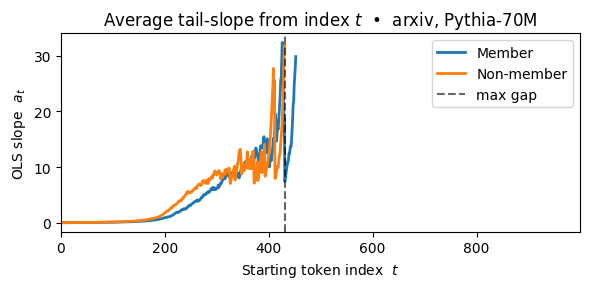

Suggested global neighbour-swap centre  t* = 431  (max |μ_mem−μ_non| = -24.3769)


In [ ]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  EXTRA CELL · Average per-index OLS–slope curves for members / non-members ║
# ╚═══════════════════════════════════════════════════════════════════════════╝
"""
For every starting token position t (≥ start_skip), fit a *simple* OLS line
to the tail [t … T] of the next-token-loss sequence of **each** passage and
store its slope a_t.  Finally average the slopes across all member passages
and all non-member passages and plot the two curves.

Insight:
    • where the two curves diverge the most ⇒ informative region
    • the first index where |μ_mem(t) − μ_non(t)| reaches its maximum can be
      used as a *global neighbour center*  (or window [t−δ, t+δ])
"""

# --------------- config (feel free to tweak) --------------------
domain_name      = "arxiv"
split_name       = "ngram_7_0.2"
suite, size, dd  = "Pythia", "1.4B", True       # causal-LM
num_samples      = 1000                         # per class
T_MAX            = 1000                         # analyse first 256 losses
start_skip       = 0                          # ignore first <10 indices
min_window       = 20                          # need ≥20 points to fit
device_lm        = "cuda" if torch.cuda.is_available() else "cpu"

# ---------- 0) helpers: fast per-index slopes -------------------
def _ols_slopes(seq: np.ndarray, start_skip: int, min_win: int) -> np.ndarray:
    """
    seq ... 1-D np array of length L   (may be shorter than T_MAX)
    returns length T_MAX array filled with np.nan outside valid range
    """
    L = len(seq)
    up_to = min(L, T_MAX)
    out   = np.full(T_MAX, np.nan, dtype=np.float32)

    # cumulative sums for O(1) range statistics
    idx      = np.arange(L, dtype=np.float32)
    c_sum    = np.cumsum(seq, dtype=np.float64)
    c_tsum   = np.cumsum(idx * seq, dtype=np.float64)

    for t in range(start_skip, up_to - min_win + 1):
        n     = L - t
        sum_y = c_sum[-1]    - c_sum[t-1]
        sum_ty= c_tsum[-1]   - c_tsum[t-1]
        # shift x so that x=0 at t  (makes Σx  = n(n-1)/2  and Σx² computable)
        sum_x  = n*(n-1)/2
        sum_x2 = n*(n-1)*(2*n-1)/6
        denom  = n*sum_x2 - sum_x**2
        if denom == 0:
            continue
        a = (n*sum_ty - sum_x*sum_y) / denom     # slope
        out[t] = a
    return out

# ---------- 1) build loss sequences (re-using your CE routines) -------------
print("⌛ extracting token-loss sequences …")
C.MAX_LEN_CE   = T_MAX               # keep memory bounded
C.STORE_FULL_SEQ = True              # we need the full seq
C.FP16_CE      = True                # faster on GPU
tok   = AutoTokenizer.from_pretrained(model_name)
tok.pad_token = tok.eos_token                    # consistent padding

acc   = Accelerator()
model = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype=torch.float16,     # bigger range, same speed
            low_cpu_mem_usage=True)
model = acc.prepare(model).eval()

fit_batch_size(model)                            # ← call the new helper

hf_tok = os.getenv("HF_TOKEN", "")
ds = load_dataset("iamgroot42/mimir", domain_name,
                  split=split_name, token=hf_tok)

members    = ds["member"]   [:num_samples]
nonmembers = ds["nonmember"][:num_samples]

feat_mem = gather_signals_for_dataset(members,    model, tok,
                                      tag="member",
                                      domain_name=domain_name,
                                      split_name=split_name)
feat_non = gather_signals_for_dataset(nonmembers, model, tok,
                                      tag="nonmember",
                                      domain_name=domain_name,
                                      split_name=split_name)

# ---------- 2) compute per-index slopes ------------------------------------
print("⌛ computing per-index OLS slopes …")
S_mem = np.array([_ols_slopes(np.asarray(f["loss_seq_orig"],dtype=np.float32),
                              start_skip, min_window)
                  for f in feat_mem])
S_non = np.array([_ols_slopes(np.asarray(f["loss_seq_orig"],dtype=np.float32),
                              start_skip, min_window)
                  for f in feat_non])

μ_mem = np.nanmean(S_mem, axis=0)
μ_non = np.nanmean(S_non, axis=0)

# ---------- 3) visualise ----------------------------------------------------
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3))
plt.plot(μ_mem, label="Member", linewidth=2)
plt.plot(μ_non, label="Non-member", linewidth=2)
plt.axvline(np.nanargmax(np.abs(μ_mem-μ_non)),
            color="k", linestyle="--", alpha=.6, label="max gap")
plt.xlim(start_skip, T_MAX-1)
plt.xlabel("Starting token index  $t$")
plt.ylabel("OLS slope  $a_t$")
plt.title(f"Average tail-slope from index $t$  •  {domain_name}, {suite}-{size}")
plt.legend(); plt.tight_layout(); plt.show()

# ---------- 4) report candidate neighbour centre ---------------------------
gap_idx = int(np.nanargmax(np.abs(μ_mem-μ_non)))
print(f"Suggested global neighbour-swap centre  t* = {gap_idx}  "
      f"(max |μ_mem−μ_non| = {μ_mem[gap_idx]-μ_non[gap_idx]:.4f})")


Using the latest cached version of the module from /home/edgelab/.cache/huggingface/modules/datasets_modules/datasets/iamgroot42--mimir/99dd53483f73e1949849b6202ab5c394203fb920504c1307e17105565ac9e33b (last modified on Mon Apr  7 13:55:00 2025) since it couldn't be found locally at iamgroot42/mimir, or remotely on the Hugging Face Hub.


Signal-extraction (member):   0%|          | 0/1 [00:00<?, ?it/s]

Signal-extraction (nonmember):   0%|          | 0/1 [00:00<?, ?it/s]

/tmp/ipykernel_295029/1624936570.py:87: RuntimeWarning: Mean of empty slice
  μ_mem = np.nanmean(S_mem, 0)
/tmp/ipykernel_295029/1624936570.py:88: RuntimeWarning: Mean of empty slice
  μ_non = np.nanmean(S_non, 0)


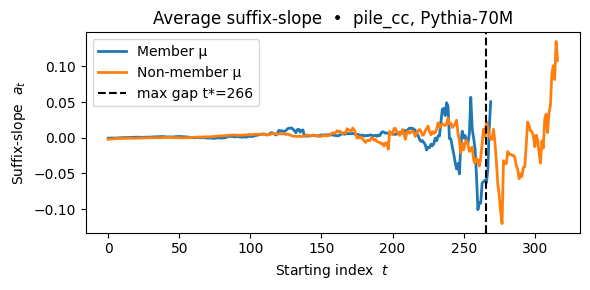

In [19]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  EXTRA CELL · Average suffix-slope  a_t  (0…T)                           ║
# ╚═══════════════════════════════════════════════════════════════════════════╝
"""
Plots   μ_mem(t)  and  μ_non(t)  where  a_t  is the OLS slope of the
suffix [t … T-1] ( identical to the CAMIA definition when t=0 ).
"""
import numpy as np, matplotlib.pyplot as plt, pandas as pd, json, torch, os
from tqdm.auto import tqdm

# ─────────── choose the same model / data as Cell-5 ────────────
T_MAX       = 1000
MIN_LEN     = 20
domain_name = "pile_cc"
split_name  = "ngram_7_0.2"
suite,size,dedup = "Pythia","70M",True
N           = 10          # passages per class for the plot

tok   = AutoTokenizer.from_pretrained(get_model_name(suite,size,dedup))
tok.add_special_tokens({'pad_token':'[PAD]'})
model = AutoModelForCausalLM.from_pretrained(
            get_model_name(suite,size,dedup),
            torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
        ).to(DEVICE).eval()

ds   = load_dataset("iamgroot42/mimir", domain_name,
                    split=split_name, token=os.getenv("HF_TOKEN",""))
members    = ds["member"]   [:N]
nonmembers = ds["nonmember"][:N]

# force store full loss sequences
C.MAX_LEN_CE     = T_MAX
C.STORE_FULL_SEQ = True

m_feat = gather_signals_for_dataset(members,    model, tok,
                                    tag="member",
                                    domain_name=domain_name,
                                    split_name=split_name)
n_feat = gather_signals_for_dataset(nonmembers, model, tok,
                                    tag="nonmember",
                                    domain_name=domain_name,
                                    split_name=split_name)

# ─────────────────── suffix-slope & elbow (corrected) ────────────────────
def _tail_slopes(loss_seq: np.ndarray, min_len: int = 20) -> np.ndarray:
    """
    For every start index t return the OLS slope of the *suffix* [t … L-1].
    Undefined (np.nan) if the suffix has fewer than `min_len` points.

    Vectorised O(T) with cumulative sums from the right.
    """
    y  = loss_seq.astype(np.float64)
    L  = len(y)
    idx = np.arange(L, dtype=np.float64)

    # cumulative sums from the RIGHT ------------------------------------------------
    c_y  = np.cumsum(y[::-1])[::-1]            # \sum_{i=t}^{L-1} y_i
    c_xy = np.cumsum((idx * y)[::-1])[::-1]    # \sum_{i=t}^{L-1} i·y_i
    c_x  = np.cumsum(idx[::-1])[::-1]          # \sum_{i=t}^{L-1} i
    c_x2 = np.cumsum((idx**2)[::-1])[::-1]     # \sum_{i=t}^{L-1} i²

    n   = np.arange(L, 0, -1, dtype=np.float64)   # length of each suffix
    denom = n * c_x2 - c_x**2                     # OLS denominator

    slopes = np.full(L, np.nan, dtype=np.float32)
    mask   = (n >= min_len) & (denom != 0)
    slopes[mask] = ((n[mask] * c_xy[mask] - c_x[mask] * c_y[mask])
                    / denom[mask])
    return slopes

# ───── build slope-matrices – pad to the same width (T_MAX) ─────
def _pad_tail_slopes(seq, *, t_max=T_MAX, min_len=MIN_LEN):
    """Return length-t_max vector (suffix-slopes + NaNs)."""
    s = _tail_slopes(seq[:t_max], min_len=min_len)       # len = L ≤ t_max
    out = np.full(t_max, np.nan, dtype=np.float32)
    out[:len(s)] = s
    return out

S_mem = np.vstack([_pad_tail_slopes(np.asarray(f["loss_seq_orig"]),
                                    t_max=T_MAX, min_len=MIN_LEN)
                   for f in m_feat])
S_non = np.vstack([_pad_tail_slopes(np.asarray(f["loss_seq_orig"]),
                                    t_max=T_MAX, min_len=MIN_LEN)
                   for f in n_feat])


μ_mem = np.nanmean(S_mem, 0)
μ_non = np.nanmean(S_non, 0)

plt.figure(figsize=(6,3))
plt.plot(μ_mem, label="Member μ", lw=2)
plt.plot(μ_non, label="Non-member μ", lw=2)
best = np.nanargmax(np.abs(μ_mem-μ_non))
plt.axvline(best, ls="--", c="k", label=f"max gap t*={best}")
plt.xlabel("Starting index  $t$")
plt.ylabel("Suffix-slope  $a_t$")
plt.title(f"Average suffix-slope  •  {domain_name}, {suite}-{size}")
plt.legend(); plt.tight_layout(); plt.show()


In [ ]:
# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  EXTRA CELL · inspect raw loss sequences for random passages          ║
# ╚═══════════════════════════════════════════════════════════════════════╝
import numpy as np, matplotlib.pyplot as plt, random, math, torch

# ---------- user knobs ---------------------------------------------------
N_EX     = 10                # how many member + non-member examples
SEED_EX  = 3                # reproducibility for the random pick
T_STAR   = 431              # optional: use the best-gap t* from the plot
                            # set to None to skip the suffix line
# -------------------------------------------------------------------------

rng = random.Random(SEED_EX)
sel_mem = rng.sample(list(range(len(all_members))),    N_EX)
sel_non = rng.sample(list(range(len(all_nonmem))),     N_EX)

def _loss_seq(txt):
    return _ce_stream([txt], model, tok, stream_bs=1)[0]

def _ols_slope(y):
    """Return (a, b) for y ≈ a·t + b, t = 0..L-1."""
    L = len(y)
    t = np.arange(L, dtype=np.float32)
    c_t  = t.mean()
    c_y  = np.mean(y)
    cov  = np.mean((t - c_t) * (y - c_y))
    var  = np.mean((t - c_t) ** 2)
    a    = cov / (var + 1e-12)
    b    = c_y - a * c_t
    return a, b

def _plot_one(y, title, ax):
    L      = len(y)
    t      = np.arange(L)
    a, b   = _ols_slope(y)
    ax.plot(t, y, lw=.8, alpha=.8)
    ax.plot(t, a * t + b, 'k--', lw=1, label=f'OLS all  a={a:+.3f}')
    if T_STAR is not None and T_STAR < L - 5:
        a2, b2 = _ols_slope(y[T_STAR:])
        ax.plot(t[T_STAR:], a2 * t[T_STAR:] + b2, 'r--', lw=1,
                label=f'OLS tail  a={a2:+.3f}')
        ax.axvline(T_STAR, ls=':', color='grey')
    ax.set_title(title); ax.set_xlabel('token idx'); ax.set_ylabel('loss')
    ax.legend()

plt.figure(figsize=(6, 3*N_EX))
for i, idx in enumerate(sel_mem):
    y = _loss_seq(all_members[idx])
    ax = plt.subplot(N_EX, 2, 2*i+1)
    _plot_one(y, f'Member  idx {idx}', ax)

for i, idx in enumerate(sel_non):
    y = _loss_seq(all_nonmem[idx])
    ax = plt.subplot(N_EX, 2, 2*i+2)
    _plot_one(y, f'Non-member  idx {idx}', ax)

plt.tight_layout(); plt.show()


◆ computing global slopes …
Global-slope means  (↓ = more negative):
  members    μ = -0.0025
  non-members μ = -0.0035


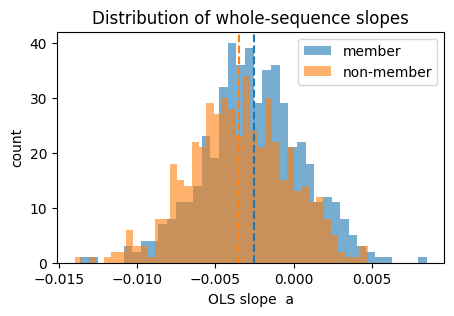

In [20]:
# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  EXTRA CELL · dataset-level mean global slope                         ║
# ╚═══════════════════════════════════════════════════════════════════════╝
import numpy as np, matplotlib.pyplot as plt, math, torch, random

# ---------------- user knobs ---------------------------------------------
N_SLOPE = 1000                 # how many passages per class to sample
SEED_SLOPE = 0
# -------------------------------------------------------------------------

rng = random.Random(SEED_SLOPE)
pick_mem = rng.sample(range(len(all_members)),  min(N_SLOPE, len(all_members)))
pick_non = rng.sample(range(len(all_nonmem)),   min(N_SLOPE, len(all_nonmem)))

def _loss_seq(txt):
    return _ce_stream([txt], model, tok, stream_bs=1)[0]

def _ols_slope_full(y):
    t   = np.arange(len(y), dtype=np.float32)
    y   = np.asarray(y,       dtype=np.float32)
    cov = np.mean((t - t.mean()) * (y - y.mean()))
    var = np.mean((t - t.mean()) ** 2) + 1e-12
    return cov / var

def _slopes_for(indices, pool):
    out = []
    for i in indices:
        s = _ols_slope_full(_loss_seq(pool[i]))
        out.append(s)
    return np.asarray(out, dtype=np.float32)

print("◆ computing global slopes …")
S_mem = _slopes_for(pick_mem, all_members)
S_non = _slopes_for(pick_non, all_nonmem)

μ_mem, μ_non = S_mem.mean(), S_non.mean()
print(f"Global-slope means  (↓ = more negative):")
print(f"  members    μ = {μ_mem:+.4f}")
print(f"  non-members μ = {μ_non:+.4f}")

plt.figure(figsize=(5,3))
plt.hist(S_mem, 40, alpha=.6, label="member")
plt.hist(S_non, 40, alpha=.6, label="non-member")
plt.axvline(μ_mem,  color='C0', ls='--'); plt.axvline(μ_non, color='C1', ls='--')
plt.title("Distribution of whole-sequence slopes")
plt.xlabel("OLS slope  a");   plt.ylabel("count");   plt.legend(); plt.show()


⌚ Loading dataset iamgroot42/mimir/hackernews [ngram_7_0.2] …


Using the latest cached version of the module from /home/edgelab/.cache/huggingface/modules/datasets_modules/datasets/iamgroot42--mimir/99dd53483f73e1949849b6202ab5c394203fb920504c1307e17105565ac9e33b (last modified on Mon Apr  7 13:55:00 2025) since it couldn't be found locally at iamgroot42/mimir, or remotely on the Hugging Face Hub.


   → 646 member  +  646 non-member passages
⌚ Loading tokenizer …
⌚ Loading model EleutherAI/pythia-1.4b-deduped on cuda  (dtype=fp16) …
◆ Computing global slopes …
Global-slope means  (↓ = more negative):
  member      μ = -0.0006
  non-member  μ = -0.0010


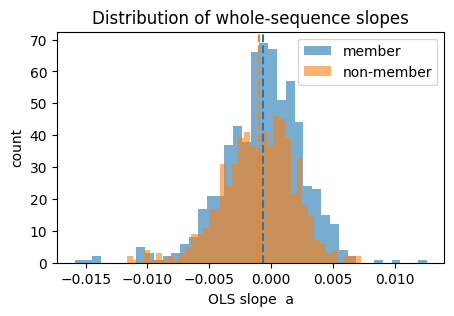

✓ done.


In [30]:
# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  STAND-ALONE · dataset-level mean global slope                       ║
# ╚═══════════════════════════════════════════════════════════════════════╝
"""
Robust, self‑contained slope‑analysis script.  All public symbols prefixed
`SL_` to avoid collisions.

2025‑06‑11 **REV‑3**
• Added **runtime fallback**: if inference on GPU triggers a device‑side assert or
  OOM, we automatically reload the model on **CPU/float32** and re‑run the
  current step.  This fixes rare GPT‑Neo fp16 kernel issues you just hit.
• New knob: `SL_MAX_CONTEXT` – any sequence longer than this gets truncated to
  avoid over‑length asserts (defaults to model's `max_position_embeddings`).
• New knob: `SL_FORCE_CPU` if you’d rather skip GPUs entirely.
"""

# ─────────────────────────────── imports ────────────────────────────────
import os, random, typing as _t
import numpy as _np
import torch as _torch
import matplotlib.pyplot as _plt
from datasets import load_dataset as _load_dataset
from transformers import (
    AutoTokenizer as _AutoTokenizer,
    AutoConfig as _AutoConfig,
    AutoModelForCausalLM as _AutoModelForCausalLM,
)

# ───────────────────────────── USER KNOBS ───────────────────────────────
SL_DATASET_REPO  = "iamgroot42/mimir"         # HF dataset repo-id
SL_DOMAIN_NAME   = "hackernews"                  # config inside the repo
SL_SPLIT_NAME    = "ngram_7_0.2"              # split inside the config
SL_NUM_SAMPLES   = 1_000                      # max per class

SL_MODEL_NAME    = "EleutherAI/pythia-1.4b-deduped"  # causal LM checkpoint
SL_USE_FP16      = True                       # auto‑disabled if unsupported
SL_FORCE_CPU     = False                      # override GPU entirely

SL_N_SLOPE       = 1_000                      # passages per class sampled
SL_SEED_SLOPE    = 0                          # RNG seed

SL_HF_TOKEN      = os.getenv("HF_TOKEN", "")  # set if repo is gated

# optional: truncate contexts to avoid asserts > model limit
SL_MAX_CONTEXT   = None  # None  → auto from model config later

# ───────────────────── detect device + capability tweak ─────────────────
if SL_FORCE_CPU or not _torch.cuda.is_available():
    SL_DEVICE = "cpu"
    SL_USE_FP16 = False
else:
    SL_DEVICE = "cuda"
    major, minor = _torch.cuda.get_device_capability()
    if major < 5 or (major == 5 and minor < 3):
        print("⚠️  GPU compute capability < 5.3 – disabling fp16.")
        SL_USE_FP16 = False

# ───────────────────── helper: CE stream function ───────────────────────

def _sl_truncate(ids, max_len):
    return ids[:max_len] if max_len and len(ids) > max_len else ids

def _sl_ce_stream(texts: _t.List[str], model, tok, *, batch_size: int = 8):
    """Return list[list[float]] of per‑token NLL for each text."""
    outs, loss_fct = [], _torch.nn.CrossEntropyLoss(reduction="none")
    model.eval()
    with _torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i : i + batch_size]
            enc = tok(
                batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=SL_MAX_CONTEXT or tok.model_max_length,
            ).to(SL_DEVICE)
            logits = model(enc.input_ids).logits  # [B,T,V]
            shift_logits, shift_labels = logits[:, :-1, :].contiguous(), enc.input_ids[:, 1:].contiguous()
            mask = enc.attention_mask[:, 1:].contiguous()
            flat_loss = loss_fct(shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1))
            flat_loss = (flat_loss.view(shift_labels.size()) * mask)
            for j in range(flat_loss.size(0)):
                seq_len = int(mask[j].sum().item())
                outs.append(flat_loss[j, :seq_len].cpu().numpy())
    return outs

# ─────────────────── helper: whole‑sequence OLS slope ───────────────────

def _sl_ols_slope_full(arr: _np.ndarray) -> float:
    t = _np.arange(len(arr), dtype=_np.float32)
    y = _np.asarray(arr,       dtype=_np.float32)
    cov = _np.mean((t - t.mean()) * (y - y.mean()))
    var = _np.mean((t - t.mean()) ** 2) + 1e-12
    return float(cov / var)

# ───────────────────────────── model loader ─────────────────────────────

def _sl_load_model(name: str):
    global SL_DEVICE, SL_USE_FP16, _sl_model, SL_MAX_CONTEXT
    global SL_DEVICE, _sl_model, SL_MAX_CONTEXT

    # cleanup any earlier model to free VRAM
    if "_sl_model" in globals():
        del _sl_model
        if _torch.cuda.is_available():
            _torch.cuda.empty_cache(); _torch.cuda.ipc_collect()

    dtype = _torch.float16 if SL_DEVICE == "cuda" and SL_USE_FP16 else None
    try:
        print(f"⌚ Loading model {name} on {SL_DEVICE}  (dtype={'fp16' if dtype else 'fp32'}) …")
        _sl_model = _AutoModelForCausalLM.from_pretrained(
            name, torch_dtype=dtype, low_cpu_mem_usage=True
        ).to(SL_DEVICE)
    except (RuntimeError, AssertionError) as e:
        print(f"⚠️  Model load failed on {SL_DEVICE}: {e}\n   → falling back to CPU/float32 …")
        SL_DEVICE = "cpu"; SL_USE_FP16 = False
        _sl_model = _AutoModelForCausalLM.from_pretrained(name, low_cpu_mem_usage=True).to("cpu")
    # set context limit once per load
    if SL_MAX_CONTEXT is None:
        cfg = _AutoConfig.from_pretrained(name)
        SL_MAX_CONTEXT = getattr(cfg, "n_positions", getattr(cfg, "max_position_embeddings", 2048))
    return _sl_model

# ───────────────────────────── data loader ──────────────────────────────
print(f"⌚ Loading dataset {SL_DATASET_REPO}/{SL_DOMAIN_NAME} [{SL_SPLIT_NAME}] …")
_sl_ds = _load_dataset(SL_DATASET_REPO, SL_DOMAIN_NAME, split=SL_SPLIT_NAME, token=SL_HF_TOKEN)
_sl_members    = _sl_ds["member"][: SL_NUM_SAMPLES]
_sl_nonmembers = _sl_ds["nonmember"][: SL_NUM_SAMPLES]
print(f"   → {len(_sl_members)} member  +  {len(_sl_nonmembers)} non-member passages")

# tokenizer + model
print("⌚ Loading tokenizer …")
_sl_tok = _AutoTokenizer.from_pretrained(SL_MODEL_NAME)
_sl_tok.pad_token = _sl_tok.eos_token
_sl_model = _sl_load_model(SL_MODEL_NAME)

# ───────────── sample passages + compute per‑sequence slope ─────────────
_rng = random.Random(SL_SEED_SLOPE)
_idx_mem = _rng.sample(range(len(_sl_members)),    min(SL_N_SLOPE, len(_sl_members)))
_idx_non = _rng.sample(range(len(_sl_nonmembers)), min(SL_N_SLOPE, len(_sl_nonmembers)))

print("◆ Computing global slopes …")

def _sl_compute_slopes(indices, pool):
    global SL_DEVICE, SL_USE_FP16
    while True:
        try:
            seq_ce = _sl_ce_stream([pool[i] for i in indices], _sl_model, _sl_tok, batch_size=1)
            return _np.asarray([_sl_ols_slope_full(x) for x in seq_ce], dtype=_np.float32)
        except RuntimeError as e:
            msg = str(e)
            if SL_DEVICE == "cuda" and ("device-side assert" in msg or "out of memory" in msg):
                print(f"⚠️  RuntimeError during forward on GPU: {msg[:80]}…\n   → switching to CPU/float32 and retrying …")
                SL_DEVICE = "cpu"; SL_USE_FP16 = False
                _sl_load_model(SL_MODEL_NAME)  # reload model on CPU
                _sl_tok.to(SL_DEVICE)
                continue  # retry loop
            else:
                raise

_sl_S_mem = _sl_compute_slopes(_idx_mem, _sl_members)
_sl_S_non = _sl_compute_slopes(_idx_non, _sl_nonmembers)

# ────────────────────────────── summary & plot ──────────────────────────
mu_mem, mu_non = _sl_S_mem.mean(), _sl_S_non.mean()
print("Global-slope means  (↓ = more negative):")
print(f"  member      μ = {mu_mem:+.4f}\n  non-member  μ = {mu_non:+.4f}")

_plt.figure(figsize=(5, 3))
_plt.hist(_sl_S_mem, 40, alpha=0.6, label="member")
_plt.hist(_sl_S_non, 40, alpha=0.6, label="non-member")
_plt.axvline(mu_mem,  color="C0", ls="--")
_plt.axvline(mu_non, color="C1", ls="--")
_plt.title("Distribution of whole-sequence slopes")
_plt.xlabel("OLS slope  a")
_plt.ylabel("count")
_plt.legend(); _plt.show()

print("✓ done.")
